In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('superstore_cleaned.csv')

# Crucial: Ensure the date is in the correct format for Task 5 later
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Preview the first few rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


Task 1: Distribution Plots

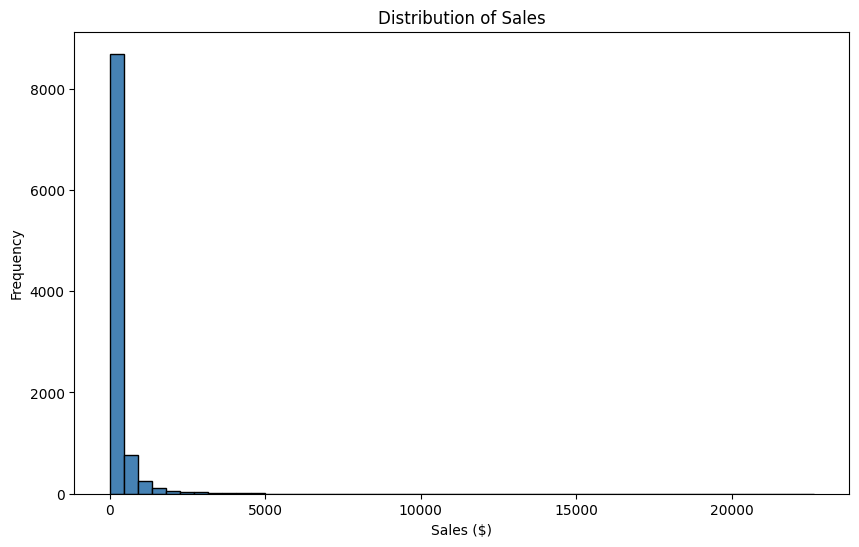

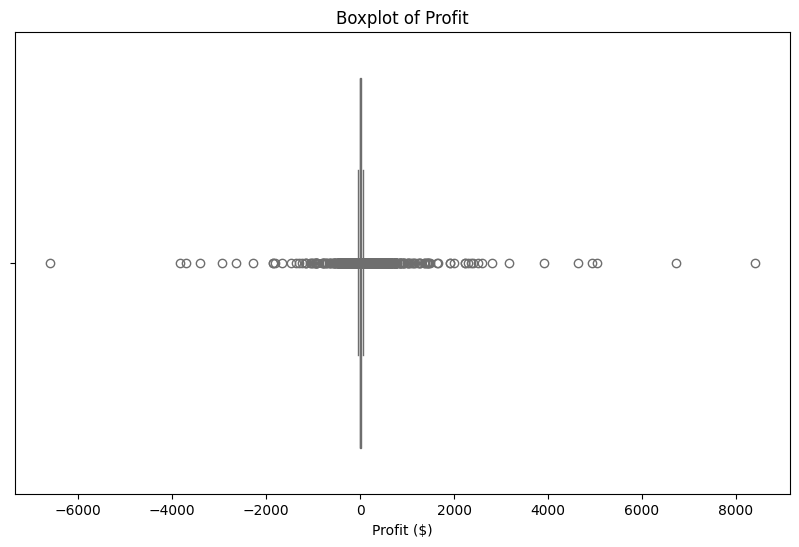

In [4]:
# 1. creating sales Histogramm
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.show()

# 2. creating box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Profit'], color='lightcoral')
plt.title('Boxplot of Profit')
plt.xlabel('Profit ($)')
plt.show()

Shape: The Sales distribution is highly right-skewed, as the vast majority of orders fall into the low-value range with a long tail extending toward expensive sales.

Observation: This indicates that most transactions involve smaller amounts, which is a common pattern in retail datasets where high-value sales are less frequent.

Quartiles: The quartiles are concentrated very close to zero, as indicated by the extremely narrow box in the center of the plot.

Outliers: There are numerous visible outliers on both ends of the distribution, representing transactions with extreme losses (down to -$6,000) and significant profits (up to $8,000).

Balance: While the outliers are spread in both directions, the presence of more distant points on the positive side suggests that the most extreme values are high-profit items.

Task 2: Category-Wise Trends

Step 1 & 2: Sales by Category

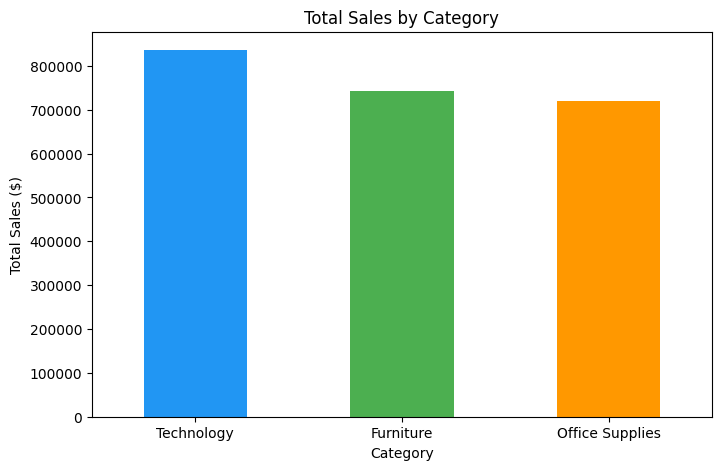

In [5]:
# calculating sales by grouply
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# creating graphics
plt.figure(figsize=(8, 5))
cat_sales.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()

Top Performer: Technology is the leading category, generating the highest total revenue at over $800,000.

Comparison: Furniture and Office Supplies follow closely behind, with each contributing between $700,000 and $750,000 in total sales.

Conclusion: While Technology is the strongest driver of revenue, the sales are relatively well-balanced across all three major categories.

Step 3: Sales by Region

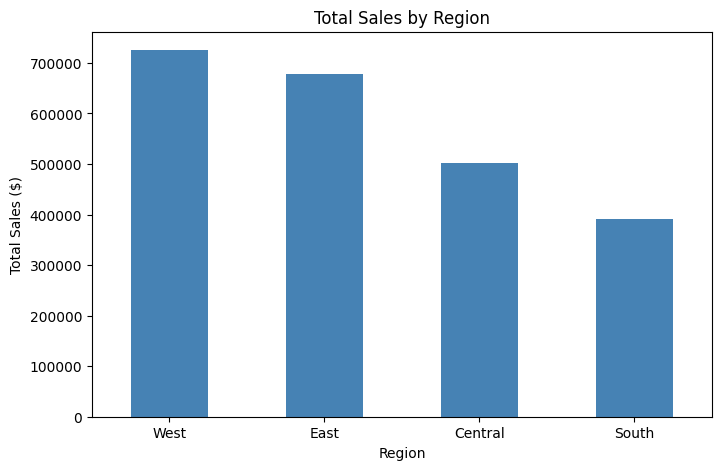

In [6]:
# calculating sales by regions
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# creating graphics
plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()

Leading Region: The West region generates the highest revenue, surpassing $700,000 in total sales.

Regional Comparison: Sales show a clear downward trend across regions, moving from the highest in the West and East to the lowest in the South, which brings in just under $400,000.

Conclusion: There is a significant performance gap between the coastal regions (West/East) and the South, suggesting a need for different marketing or inventory strategies in those areas.

Task 3: Outlier Identification

In [7]:
# step 1: Q1, Q3 and IQR calculating
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")

# step 2: definig the borders of outliner 
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Pastki chegara: {lower_bound:.2f}, Yuqori chegara: {upper_bound:.2f}")

# step3. calculating outliers
outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]
outlier_percentage = (len(outliers) / len(df)) * 100
print(f"Outliers soni: {len(outliers)} ta ({outlier_percentage:.2f}%)")

Q1: 1.73, Q3: 29.36, IQR: 27.64
Pastki chegara: -39.72, Yuqori chegara: 70.82
Outliers soni: 1881 ta (18.27%)


Outlier Count: I identified 1,881 outliers in the Profit column, which accounts for 18.27% of the total dataset.

Boundaries: Any transaction with a profit below -$39.72 or above $70.82 is mathematically considered an outlier based on the IQR method.

Business Insight: A high percentage of outliers (18%) suggests that the business frequently experiences transactions with significantly higher profits or deeper losses than the average sale, indicating high volatility in profit margins.

Task 4: Correlation Heatmap

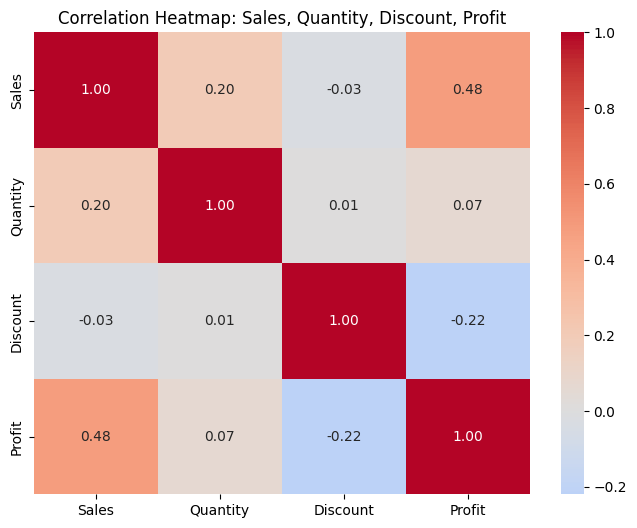

In [8]:
# step1: choosing only numerical columns and calculating correlations.
numerical_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]
corr_matrix = numerical_cols.corr()

# step 2: creating heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit')
plt.show()

Strongest Positive Relationship: Sales and Profit have the strongest positive correlation (0.48), indicating that as revenue increases, profit generally follows an upward trend.

Notable Negative Relationship: Discount and Profit show a negative correlation of -0.22, suggesting that higher discounts are often associated with a decrease in overall profit.

Weak Relationship: There is very little correlation between Quantity and Profit (0.07), meaning that simply selling more items does not necessarily guarantee a proportional increase in profit.

Task 5: Time-Based Trend

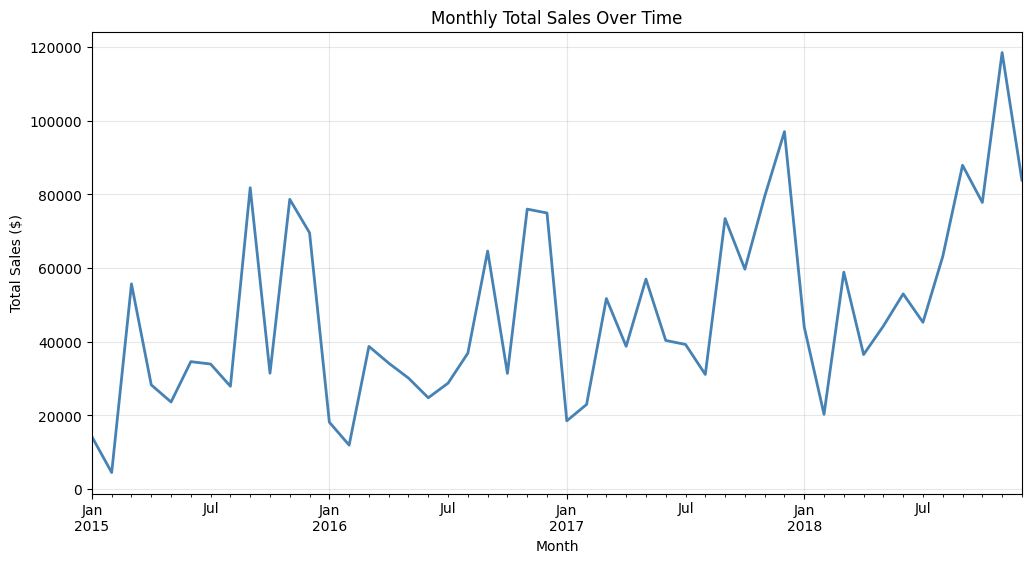

In [9]:
# step 1: grouping the data to total monthly sales
# 'ME' - last month (Month End) 
monthly_sales = df.resample('ME', on='Order Date')['Sales'].sum()

# step 2: creating line graph
plt.figure(figsize=(12, 6))
monthly_sales.plot(color='steelblue', linewidth=2)
plt.title('Monthly Total Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.show()

Seasonality: The sales trend shows a clear seasonal pattern with consistent spikes in November and December, followed by significant dips every January.

Growth: Over the four-year period, there is a visible upward trajectory in revenue, with the highest peak occurring at the end of 2018.

Task 6: Reflection & Conclusion

1. Why is the Sales distribution right-skewed?

Answer: The distribution is right-skewed because the store handles a large volume of small-value orders, while high-value sales (expensive technology or large furniture) occur much less frequently.

2. Should we remove the outliers in the Profit column? Why or why not?

Answer: No, we should not remove them. In this business context, outliers represent significant profits or major losses. Removing them would hide critical information about which products are highly profitable or which ones are causing financial leaks.

3. What is the most important trend you noticed in the time-series analysis?

Answer: The most critical trend is the strong end-of-year seasonality. Sales consistently peak in Q4 (November-December) and drop sharply in January. This suggests the business should prepare inventory and staffing specifically for the holiday rush.